# imports and data loading

In [1]:
from model_pipelines.xgb_classifier import *
from model_pipelines.check_calibration import *
from model_pipelines.auxilliary_functions import *
from eda.scoring_function import score_model_optimal_k
from sklearn.model_selection import train_test_split
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import os
from pathlib import Path

In [2]:
# do not change project up to project root
PROJECT_FOLDER_NAME = "-Cost-Sensitive-Predictive-Modeling"
current_path = Path(os.getcwd()).resolve()
project_root = Path(*current_path.parts[:current_path.parts.index(PROJECT_FOLDER_NAME) + 1])
#======== run variables ======================================
EXP_NAME = "corr" # set run name
EXP_DIR = project_root / "experiment_results" / EXP_NAME
EXP_DIR.mkdir(parents=True, exist_ok=True)
#filenames to save output
FILE_SUBSETS_RESULTS_DF= EXP_DIR / "all_subsets_results_before_tuning.csv"
FILE_ALL_SUBSETS_DICT= EXP_DIR / "all_subsets_dict.json"
FILE_BEST_AFTER_TUNING = EXP_DIR / "top10_subsets_hyperparam_tuning_dict.json"
FILE_MULTI_RUN_TOP10_SUBSETS_RESULTS= EXP_DIR / "top10_subsets_mulitrun_check_dict.json"
FILE_CV_TOP10_SUBSETS_RESULTS= EXP_DIR / "top10_subsets_cv_dict.json"
PLOT_DIR = EXP_DIR / "plots"
PLOT_DIR.mkdir(parents=True, exist_ok=True)
# Check of directories
print(f" Root: {project_root}")
print(EXP_DIR)

 Root: C:\Users\andrz\-Cost-Sensitive-Predictive-Modeling
C:\Users\andrz\-Cost-Sensitive-Predictive-Modeling\experiment_results\corr


In [3]:
#load data (full training data)
y=pd.read_csv("C:\\Users\\andrz\\Downloads\\data\\data\\y_train.txt")
x=pd.read_csv("C:\\Users\\andrz\\Downloads\\data\\data\\x_train.txt",sep=" ")

In [4]:
# load a dict of all columns selected (another dict may need to be passed)
selected_cols_dict=joblib.load("C:\\Users\\andrz\\Downloads\\selected_features_dictionary.joblib")


In [7]:
print(selected_cols_dict.keys())

dict_keys(['rf_1000_1', 'rf_1000_3', 'rf_3000_1', 'rf_3000_3', 'xgb_1000_1', 'xgb_1000_3', 'xgb_3000_1', 'xgb_3000_3', 'shap_rf_1000_1', 'shap_rf_1000_3', 'shap_rf_3000_1', 'shap_rf_3000_3', 'shap_xgb_1000_1', 'shap_xgb_1000_3', 'shap_xgb_3000_1', 'shap_xgb_3000_3', 'KS', 'Corr', 'MI'])


In [8]:
#extract the right subset of columns (3 options - for all features, for model features, for statistical features, select one and comment out the others)
selected_second_level_subset=selected_cols_dict['Corr'] #for one statistical method, just change the key if needed
selected_second_level_subset=selected_second_level_subset[:10] #get only 10 best features (speeds up computation massivly)
# selected_second_level_subset=unpack_whole_feature_dict(selected_cols_dict,extract='common') # for features found by all methods, if all features found by different methods, use extract='all_found'
# selected_second_level_subset=unpack_model_feature_dict(selected_cols_dict,'rf',extract='common') # for selecting the features found by all xgb (or possibly rf - change second argument) models, extract works as in the previous example

In [9]:
x_t,x_tst,y_t,y_tst=train_test_split(x.loc[:,selected_second_level_subset],y,test_size=0.2,random_state=7)

# check all combinations of the selected features for one configuration of xgb model

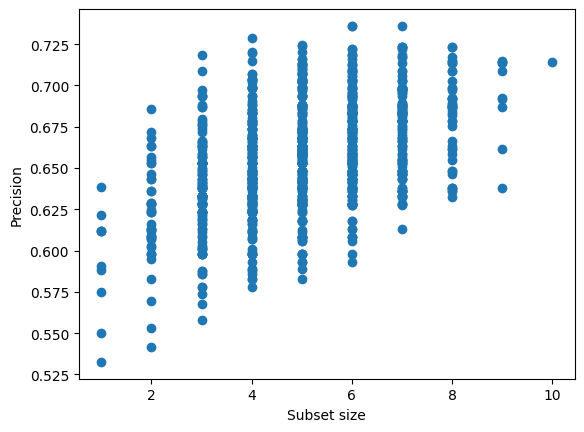

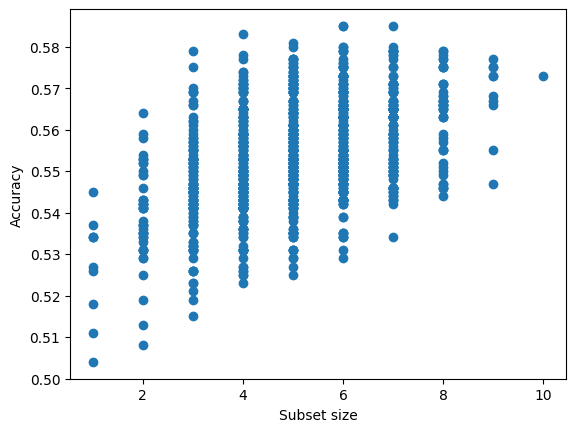

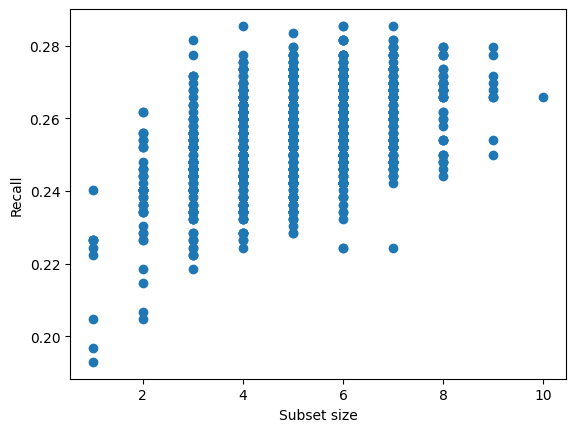

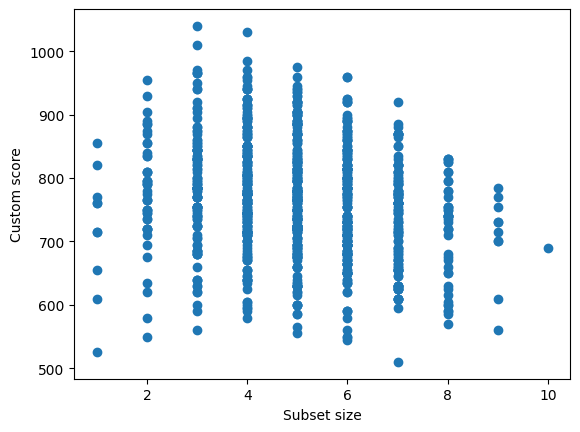

In [10]:
best_model,best_ft,df,all_subsets=train_model_all_combinations(x_t,y_t,x_tst,y_tst,max_subset=selected_second_level_subset,return_metrics=True)

In [17]:
# #reload if needed:
# df=pd.read_csv(FILE_SUBSETS_RESULTS_DF,index_col='Subset index')
# with open(FILE_ALL_SUBSETS_DICT, 'r') as file:
#     all_subsets = json.load(file)
# all_subsets = {int(k): v for k, v in all_subsets.items()}

In [11]:
df=df.sort_values(by="Precision", ascending=False)
df_top10_prec=df.head(10)

print(df_top10_prec)

              Custom Score  Precision  Accuracy    Recall
Subset index                                             
752                  960.0   0.736041     0.585  0.285433
744                  960.0   0.736041     0.585  0.285433
760                  920.0   0.736041     0.585  0.285433
224                 1030.0   0.728643     0.583  0.285433
228                  960.0   0.724490     0.580  0.279528
736                  975.0   0.723618     0.581  0.283465
762                  830.0   0.723077     0.579  0.277559
500                  870.0   0.723077     0.579  0.277559
508                  830.0   0.723077     0.579  0.277559
754                  870.0   0.723077     0.579  0.277559


In [12]:
df=df.sort_values(by="Custom Score", ascending=False)
df_top10_score=df.head(10)

print(df_top10_score)

              Custom Score  Precision  Accuracy    Recall
Subset index                                             
223                 1040.0   0.718593     0.579  0.281496
224                 1030.0   0.728643     0.583  0.285433
192                 1010.0   0.708543     0.575  0.277559
672                  985.0   0.719388     0.578  0.277559
736                  975.0   0.723618     0.581  0.283465
66                   970.0   0.696970     0.570  0.271654
704                  970.0   0.720207     0.577  0.273622
199                  965.0   0.693467     0.569  0.271654
207                  965.0   0.693467     0.569  0.271654
703                  965.0   0.693467     0.569  0.271654


In [13]:
df.to_csv(FILE_SUBSETS_RESULTS_DF, index=True)
save_dict_to_json(all_subsets,FILE_ALL_SUBSETS_DICT)


Successfully saved data to C:\Users\andrz\-Cost-Sensitive-Predictive-Modeling\experiment_results\corr\all_subsets_dict.json


# for top 10 feature subsets conduct hyperparameter tuning, at one split.

In [14]:
#initialize a dict for the results of hyperparameter tuning for top 10 subsets
top10_hyperparameter_tuning_result_dict = {
    idx: {}
    for idx in df_top10_prec.index
}

In [15]:
for ind in df_top10_prec.index:
    print("=========================================")
    print(f"subset {ind}: {all_subsets[ind]}")
    print("=========================================")
    best_c_hyperparams,best_p_hyperparams=final_xgb_hyperparameter_grid_optimizer(x_t.loc[:,all_subsets[ind]],y_t,x_tst.loc[:,all_subsets[ind]],y_tst)
    xgb=XGBClassifier(max_depth=best_c_hyperparams['max_depth'],n_estimators=best_c_hyperparams['n_estimators'],learning_rate=best_c_hyperparams['lr'],random_state=7)
    xgb.fit(x_t.loc[:,all_subsets[ind]],y_t)
    y_pred_proba=xgb.predict_proba(x_tst.loc[:,all_subsets[ind]])[:,1]
    best_score,best_threshold, best_k, best_fp, best_tp=score_model_optimal_k(y_tst,y_pred_proba,len(all_subsets[ind]),keep_fp_tp=True,max_k=200,feature_penalty=40)
    top10_hyperparameter_tuning_result_dict[ind]['best_c_hyperparams']=best_c_hyperparams
    top10_hyperparameter_tuning_result_dict[ind]['best_p_hyperparams']=best_p_hyperparams
    top10_hyperparameter_tuning_result_dict[ind]['best_threshold']=best_threshold
    top10_hyperparameter_tuning_result_dict[ind]['best_score']=best_score
    top10_hyperparameter_tuning_result_dict[ind]['best_fp']=best_fp
    top10_hyperparameter_tuning_result_dict[ind]['best_tp']=best_tp
    top10_hyperparameter_tuning_result_dict[ind]['subset_list']=all_subsets[ind] # added for easier reloading
    print("=======================================")
    print(f"Score for subset {all_subsets[ind]}")
    print(f"best score: {best_score}, best threshold: {best_threshold}, fp:{best_fp}, tp:{best_tp}")
    print(f"best custom hyperparameters: {best_c_hyperparams}")
    print(f"best precision hyperparameters: {best_p_hyperparams}")
    print("=======================================")
save_dict_to_json(top10_hyperparameter_tuning_result_dict,FILE_BEST_AFTER_TUNING)

subset 752: ['V390', 'V32', 'V11', 'V199', 'V345', 'V309']
Score for subset ['V390', 'V32', 'V11', 'V199', 'V345', 'V309']
best score: 890, best threshold: 0.6079614162445068, fp:58, tp:142
best custom hyperparameters: {'max_depth': 1, 'n_estimators': 1000, 'lr': 0.1}
best precision hyperparameters: {'max_depth': 1, 'n_estimators': 2000, 'lr': 0.1}
subset 744: ['V390', 'V175', 'V11', 'V199', 'V345', 'V309']
Score for subset ['V390', 'V175', 'V11', 'V199', 'V345', 'V309']
best score: 890, best threshold: 0.6079614162445068, fp:58, tp:142
best custom hyperparameters: {'max_depth': 1, 'n_estimators': 1000, 'lr': 0.1}
best precision hyperparameters: {'max_depth': 1, 'n_estimators': 2000, 'lr': 0.1}
subset 760: ['V390', 'V175', 'V32', 'V11', 'V199', 'V345', 'V309']
Score for subset ['V390', 'V175', 'V32', 'V11', 'V199', 'V345', 'V309']
best score: 850, best threshold: 0.6079614162445068, fp:58, tp:142
best custom hyperparameters: {'max_depth': 1, 'n_estimators': 1000, 'lr': 0.1}
best precis

In [16]:
#create a df with the scores of the top10 subsets for easier further selection and get 4 top subset indices
auxliary_data = [
    {'ind': key, 'score': value['best_score']}
    for key, value in top10_hyperparameter_tuning_result_dict.items()
]
auxiliary_df = pd.DataFrame(auxliary_data)
auxiliary_df=auxiliary_df.sort_values(by="score", ascending=False)
top10_subset_indices=auxiliary_df.head(10).loc[:,"ind"].tolist()
# a dictionary for results of multi-split check
top10_multisplit_result_dict = {
    idx: {}
    for idx in top10_subset_indices
}

In [17]:
print(auxiliary_df)

   ind  score
3  224   1045
5  736   1005
4  228    995
9  754    925
7  500    895
0  752    890
1  744    890
6  762    885
8  508    855
2  760    850


In [18]:
for ind in top10_subset_indices:
    scores,precs=check_xgb_model_with_multi_split(x.loc[:, top10_hyperparameter_tuning_result_dict[ind]['subset_list']],y,max_depth=top10_hyperparameter_tuning_result_dict[ind]['best_c_hyperparams']['max_depth'], n_estimators=top10_hyperparameter_tuning_result_dict[ind]['best_c_hyperparams']['n_estimators'], learning_rate=top10_hyperparameter_tuning_result_dict[ind]['best_c_hyperparams']['lr'],n_checks=50,threshold=top10_hyperparameter_tuning_result_dict[ind]['best_threshold'])
    top10_multisplit_result_dict[ind]['scores']=scores
    top10_multisplit_result_dict[ind]['precs']=precs
    print(f"check done for index: {ind}")
save_dict_to_json(top10_multisplit_result_dict,FILE_MULTI_RUN_TOP10_SUBSETS_RESULTS)

no. of positives in splitted sample: 498
no. of positives in splitted sample: 498
no. of positives in splitted sample: 498
no. of positives in splitted sample: 498
no. of positives in splitted sample: 498
no. of positives in splitted sample: 498
no. of positives in splitted sample: 498
no. of positives in splitted sample: 498
no. of positives in splitted sample: 498
no. of positives in splitted sample: 498
no. of positives in splitted sample: 498
no. of positives in splitted sample: 498
no. of positives in splitted sample: 498
no. of positives in splitted sample: 498
no. of positives in splitted sample: 498
no. of positives in splitted sample: 498
no. of positives in splitted sample: 498
no. of positives in splitted sample: 498
no. of positives in splitted sample: 498
no. of positives in splitted sample: 498
no. of positives in splitted sample: 498
no. of positives in splitted sample: 498
no. of positives in splitted sample: 498
no. of positives in splitted sample: 498
no. of positives

C:\Users\andrz\AppData\Local\Temp\ipykernel_11976\2730525874.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_to_plot, labels=labels)


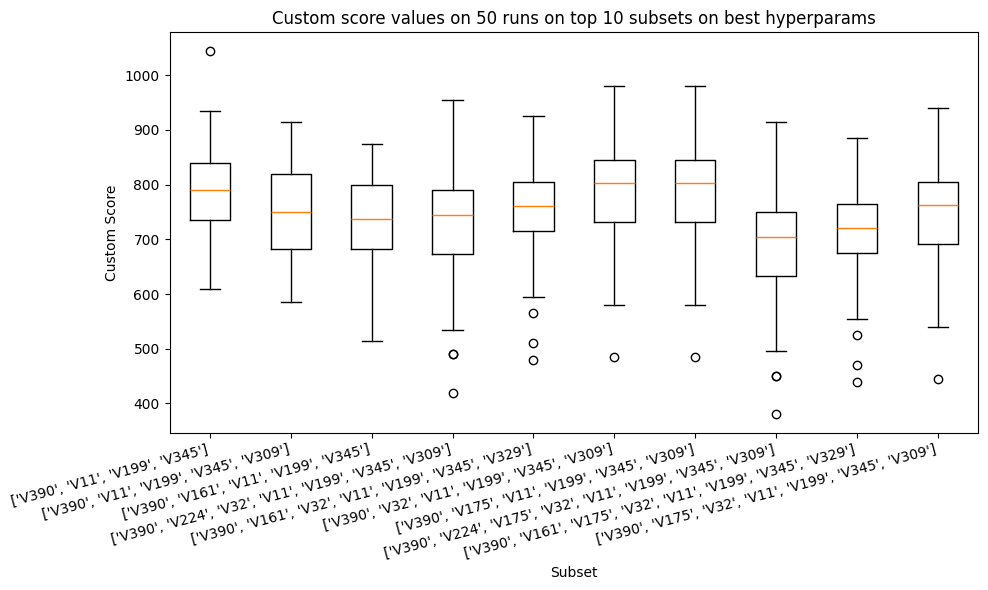

In [19]:
#plotting - custom scores (may be optional, but probably at this level the best will be selected manually)
data_to_plot = []
labels = []

for ind in top10_subset_indices:
    data_to_plot.append(top10_multisplit_result_dict[ind]['scores'])
    labels.append(str(top10_hyperparameter_tuning_result_dict[ind]['subset_list']))

plt.figure(figsize=(10, 6))
plt.boxplot(data_to_plot, labels=labels)

plt.xlabel("Subset")
plt.ylabel("Custom Score")
plt.title("Custom score values on 50 runs on top 10 subsets on best hyperparams")
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.savefig(Path(PLOT_DIR / "custom_score_50runs_boxplot.png"))
plt.show()

C:\Users\andrz\AppData\Local\Temp\ipykernel_11976\3926348023.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_to_plot, labels=labels)


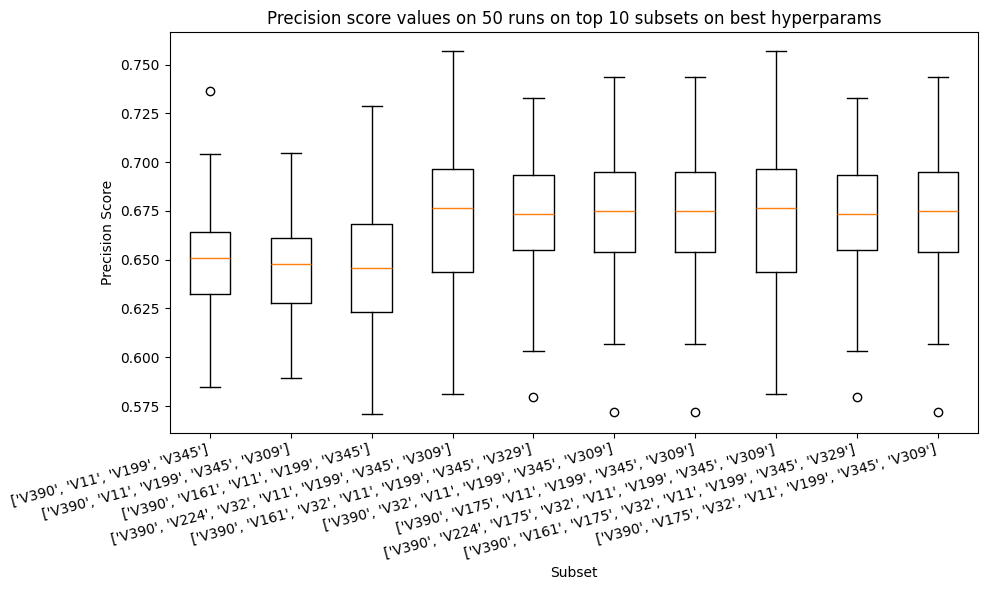

In [20]:
#plotting - precisions (may be optional, but probably at this level the best will be selected manually)
data_to_plot = []
labels = []

for ind in top10_subset_indices:
    data_to_plot.append(top10_multisplit_result_dict[ind]['precs'])
    labels.append(str(top10_hyperparameter_tuning_result_dict[ind]['subset_list']))

plt.figure(figsize=(10, 6))
plt.boxplot(data_to_plot, labels=labels)

plt.xlabel("Subset")
plt.ylabel("Precision Score")
plt.title("Precision score values on 50 runs on top 10 subsets on best hyperparams")
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.savefig(Path(PLOT_DIR / "precision_50runs_boxplot.png"))
plt.show()

In [21]:
top10_cv_result_dict={
    ind:{}
    for ind in top10_subset_indices
}
for ind in top10_subset_indices:
    print(f"checking cv score for subset: {top10_hyperparameter_tuning_result_dict[ind]['subset_list']}")
    model=XGBClassifier(max_depth=top10_hyperparameter_tuning_result_dict[ind]['best_c_hyperparams']['max_depth'])
    all_y_test,all_y_prob=get_cv_calibration_predictions(model,x.loc[:,top10_hyperparameter_tuning_result_dict[ind]['subset_list']],y)
    all_y_pred=(all_y_prob>score_model_optimal_k(all_y_test,all_y_prob,n_vars=len(top10_hyperparameter_tuning_result_dict[ind]['subset_list']))[1]).astype(int)
    print(precision_score(all_y_test,all_y_pred))
    top10_cv_result_dict[ind]["precision"]=precision_score(all_y_test,all_y_pred)
    top10_cv_result_dict[ind]["accuracy"]=accuracy_score(all_y_test,all_y_pred)
    top10_cv_result_dict[ind]["recall"]=recall_score(all_y_test,all_y_pred)
    top10_cv_result_dict[ind]["cv_custom_score"],top10_cv_result_dict[ind]["cv_best_threshold"]=score_model_optimal_k(all_y_test,all_y_prob,n_vars=len(top10_hyperparameter_tuning_result_dict[ind]['subset_list']),keep_fp_tp=True)[:2]
    print(score_model_optimal_k(all_y_test,all_y_prob,n_vars=len(top10_hyperparameter_tuning_result_dict[ind]['subset_list']),keep_fp_tp=True))
    print("===============================================")
save_dict_to_json(top10_cv_result_dict,FILE_CV_TOP10_SUBSETS_RESULTS)

checking cv score for subset: ['V390', 'V11', 'V199', 'V345']
0.6646646646646647
(4175, np.float32(0.5873814), 1000, 335, 665)
checking cv score for subset: ['V390', 'V11', 'V199', 'V345', 'V309']
0.6596596596596597
(3900, np.float32(0.5907438), 1000, 340, 660)
checking cv score for subset: ['V390', 'V161', 'V11', 'V199', 'V345']
0.6686807653575025
(4005, np.float32(0.58507407), 994, 329, 665)
checking cv score for subset: ['V390', 'V224', 'V32', 'V11', 'V199', 'V345', 'V309']
0.6770938446014128
(3720, np.float32(0.6301576), 992, 320, 672)
checking cv score for subset: ['V390', 'V161', 'V32', 'V11', 'V199', 'V345', 'V329']
0.6579476861167002
(3450, np.float32(0.64676833), 995, 340, 655)
checking cv score for subset: ['V390', 'V32', 'V11', 'V199', 'V345', 'V309']
0.6750503018108652
(3905, np.float32(0.6008909), 995, 323, 672)
checking cv score for subset: ['V390', 'V175', 'V11', 'V199', 'V345', 'V309']
0.6750503018108652
(3905, np.float32(0.6008909), 995, 323, 672)
checking cv score for

# before decision run calibration check

checking calibration for subset ['V390', 'V11', 'V199', 'V345']
Bin  1 | n= 500 | mean_pred=0.338 | frac_pos=0.346
Bin  2 | n= 497 | mean_pred=0.401 | frac_pos=0.445
Bin  3 | n= 503 | mean_pred=0.423 | frac_pos=0.419
Bin  4 | n= 500 | mean_pred=0.442 | frac_pos=0.476
Bin  5 | n= 497 | mean_pred=0.463 | frac_pos=0.467
Bin  6 | n= 503 | mean_pred=0.487 | frac_pos=0.477
Bin  7 | n= 500 | mean_pred=0.520 | frac_pos=0.480
Bin  8 | n= 500 | mean_pred=0.561 | frac_pos=0.536
Bin  9 | n= 500 | mean_pred=0.618 | frac_pos=0.634
Bin 10 | n= 500 | mean_pred=0.730 | frac_pos=0.696


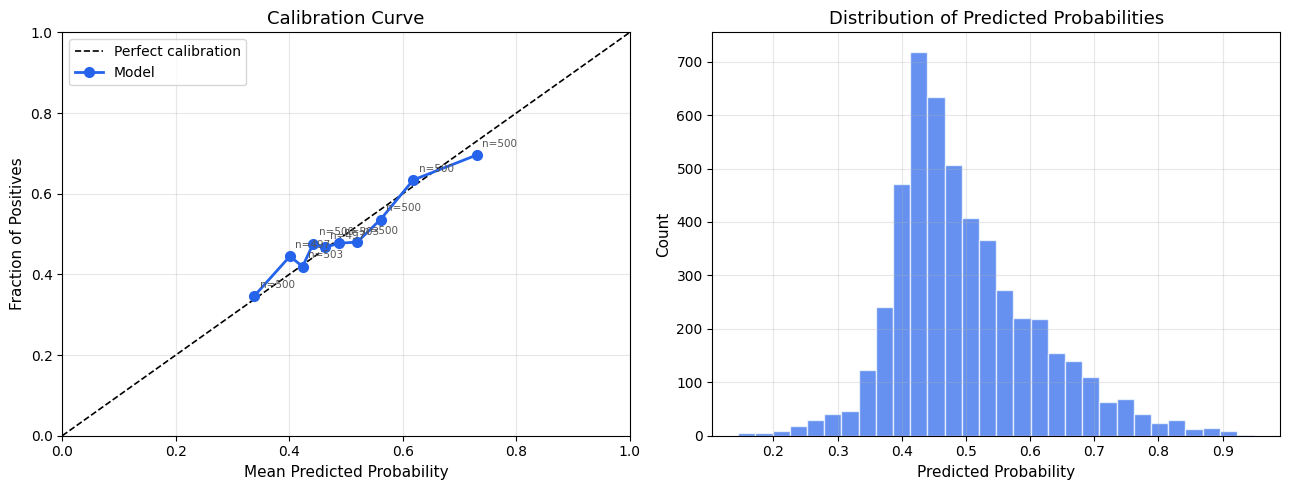

checking calibration for subset ['V390', 'V11', 'V199', 'V345', 'V309']
Bin  1 | n= 500 | mean_pred=0.327 | frac_pos=0.328
Bin  2 | n= 500 | mean_pred=0.391 | frac_pos=0.412
Bin  3 | n= 500 | mean_pred=0.417 | frac_pos=0.450
Bin  4 | n= 500 | mean_pred=0.441 | frac_pos=0.462
Bin  5 | n= 500 | mean_pred=0.468 | frac_pos=0.458
Bin  6 | n= 500 | mean_pred=0.494 | frac_pos=0.462
Bin  7 | n= 500 | mean_pred=0.525 | frac_pos=0.510
Bin  8 | n= 500 | mean_pred=0.565 | frac_pos=0.574
Bin  9 | n= 500 | mean_pred=0.622 | frac_pos=0.616
Bin 10 | n= 500 | mean_pred=0.733 | frac_pos=0.704


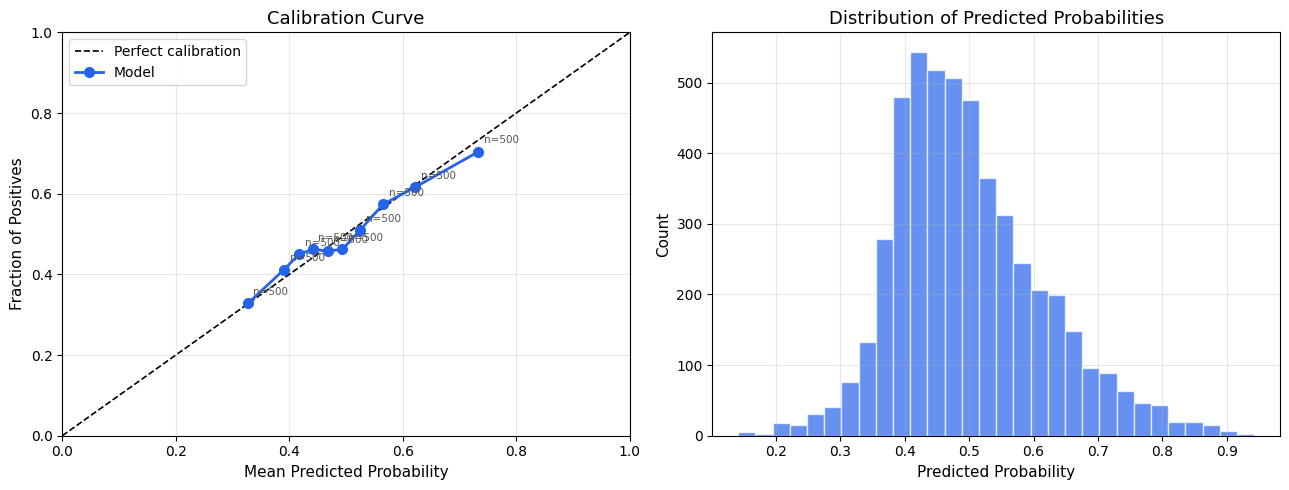

checking calibration for subset ['V390', 'V161', 'V11', 'V199', 'V345']
Bin  1 | n= 497 | mean_pred=0.337 | frac_pos=0.332
Bin  2 | n= 503 | mean_pred=0.401 | frac_pos=0.465
Bin  3 | n= 500 | mean_pred=0.424 | frac_pos=0.404
Bin  4 | n= 500 | mean_pred=0.443 | frac_pos=0.470
Bin  5 | n= 500 | mean_pred=0.463 | frac_pos=0.486
Bin  6 | n= 500 | mean_pred=0.487 | frac_pos=0.454
Bin  7 | n= 500 | mean_pred=0.519 | frac_pos=0.488
Bin  8 | n= 500 | mean_pred=0.559 | frac_pos=0.544
Bin  9 | n= 500 | mean_pred=0.618 | frac_pos=0.632
Bin 10 | n= 500 | mean_pred=0.733 | frac_pos=0.700


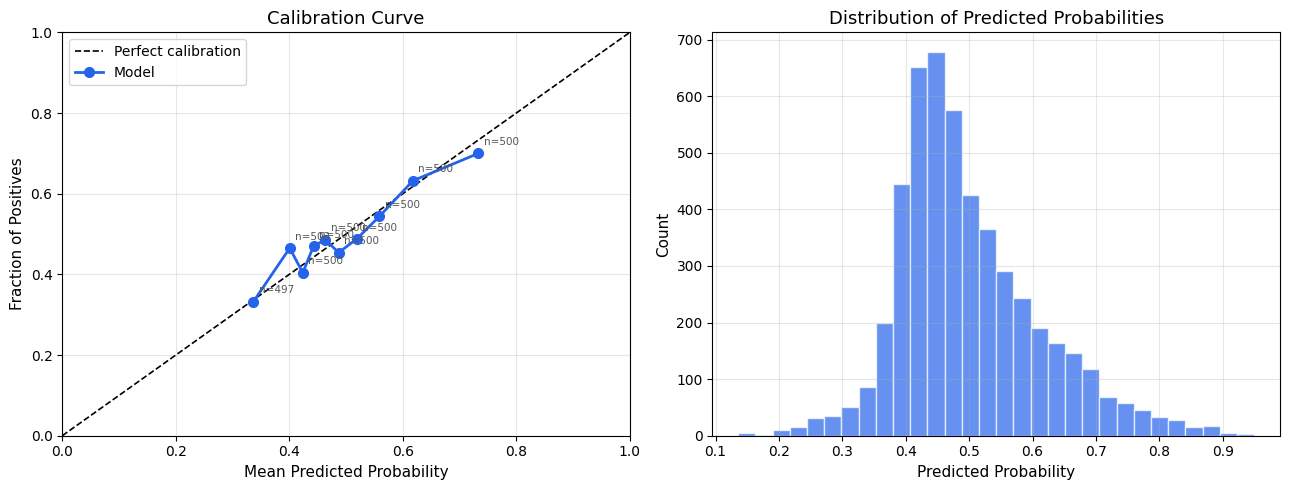

checking calibration for subset ['V390', 'V224', 'V32', 'V11', 'V199', 'V345', 'V309']
Bin  1 | n= 500 | mean_pred=0.263 | frac_pos=0.330
Bin  2 | n= 500 | mean_pred=0.344 | frac_pos=0.402
Bin  3 | n= 500 | mean_pred=0.386 | frac_pos=0.416
Bin  4 | n= 500 | mean_pred=0.424 | frac_pos=0.390
Bin  5 | n= 500 | mean_pred=0.460 | frac_pos=0.458
Bin  6 | n= 500 | mean_pred=0.500 | frac_pos=0.482
Bin  7 | n= 500 | mean_pred=0.545 | frac_pos=0.550
Bin  8 | n= 500 | mean_pred=0.598 | frac_pos=0.602
Bin  9 | n= 500 | mean_pred=0.668 | frac_pos=0.664
Bin 10 | n= 500 | mean_pred=0.795 | frac_pos=0.682


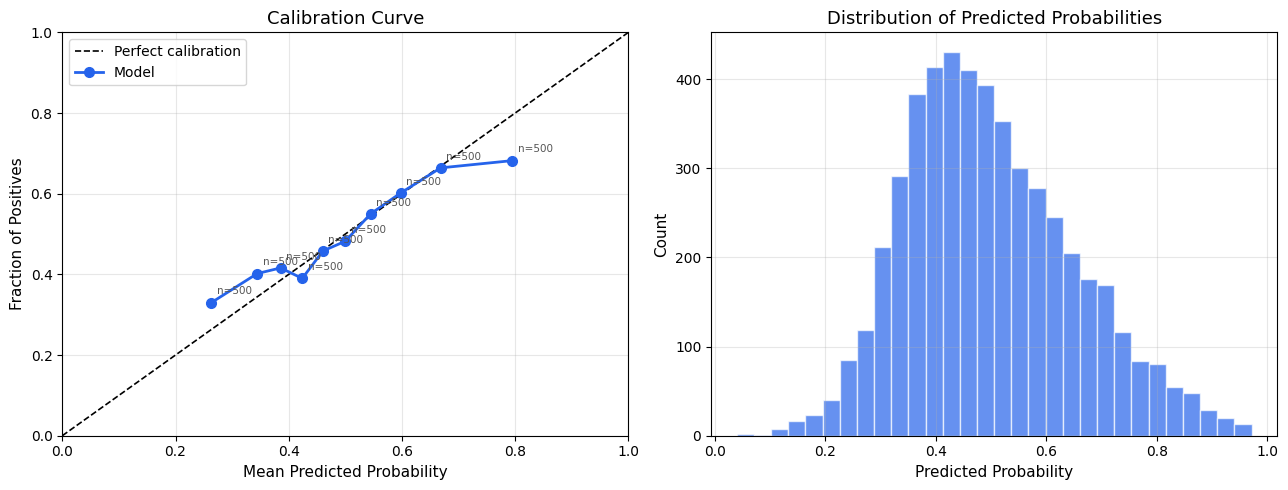

checking calibration for subset ['V390', 'V161', 'V32', 'V11', 'V199', 'V345', 'V329']
Bin  1 | n= 500 | mean_pred=0.221 | frac_pos=0.332
Bin  2 | n= 500 | mean_pred=0.317 | frac_pos=0.428
Bin  3 | n= 500 | mean_pred=0.370 | frac_pos=0.458
Bin  4 | n= 500 | mean_pred=0.416 | frac_pos=0.426
Bin  5 | n= 500 | mean_pred=0.458 | frac_pos=0.472
Bin  6 | n= 500 | mean_pred=0.505 | frac_pos=0.478
Bin  7 | n= 500 | mean_pred=0.555 | frac_pos=0.500
Bin  8 | n= 500 | mean_pred=0.613 | frac_pos=0.572
Bin  9 | n= 500 | mean_pred=0.696 | frac_pos=0.608
Bin 10 | n= 500 | mean_pred=0.834 | frac_pos=0.702


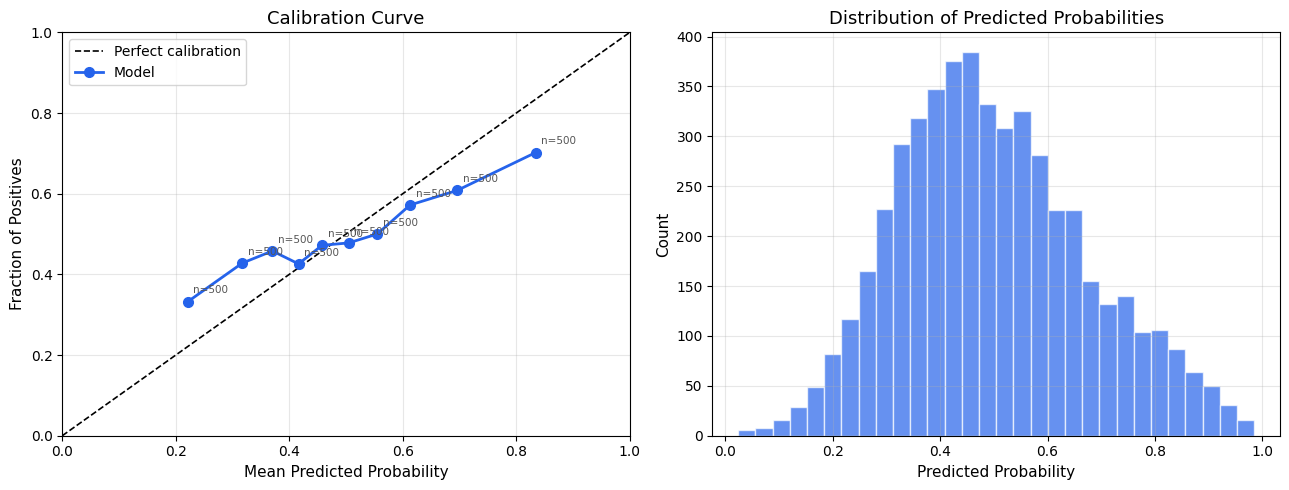

checking calibration for subset ['V390', 'V32', 'V11', 'V199', 'V345', 'V309']
Bin  1 | n= 500 | mean_pred=0.314 | frac_pos=0.314
Bin  2 | n= 500 | mean_pred=0.377 | frac_pos=0.386
Bin  3 | n= 500 | mean_pred=0.409 | frac_pos=0.424
Bin  4 | n= 500 | mean_pred=0.437 | frac_pos=0.460
Bin  5 | n= 500 | mean_pred=0.465 | frac_pos=0.444
Bin  6 | n= 500 | mean_pred=0.494 | frac_pos=0.484
Bin  7 | n= 500 | mean_pred=0.529 | frac_pos=0.518
Bin  8 | n= 499 | mean_pred=0.572 | frac_pos=0.601
Bin  9 | n= 501 | mean_pred=0.634 | frac_pos=0.609
Bin 10 | n= 500 | mean_pred=0.751 | frac_pos=0.736


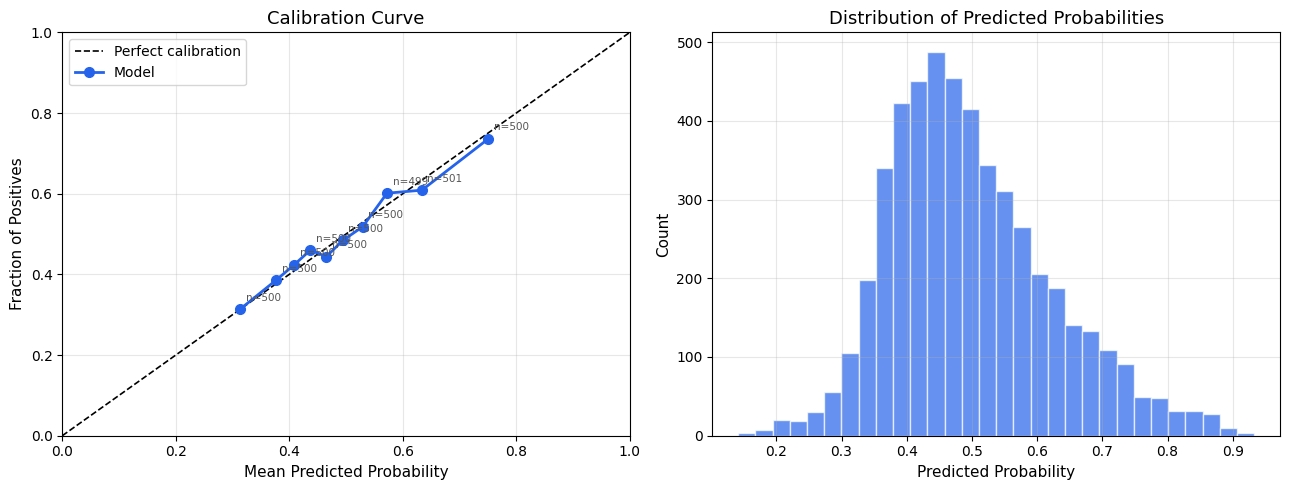

checking calibration for subset ['V390', 'V175', 'V11', 'V199', 'V345', 'V309']
Bin  1 | n= 500 | mean_pred=0.314 | frac_pos=0.314
Bin  2 | n= 500 | mean_pred=0.377 | frac_pos=0.386
Bin  3 | n= 500 | mean_pred=0.409 | frac_pos=0.424
Bin  4 | n= 500 | mean_pred=0.437 | frac_pos=0.460
Bin  5 | n= 500 | mean_pred=0.465 | frac_pos=0.444
Bin  6 | n= 500 | mean_pred=0.494 | frac_pos=0.484
Bin  7 | n= 500 | mean_pred=0.529 | frac_pos=0.518
Bin  8 | n= 499 | mean_pred=0.572 | frac_pos=0.601
Bin  9 | n= 501 | mean_pred=0.634 | frac_pos=0.609
Bin 10 | n= 500 | mean_pred=0.751 | frac_pos=0.736


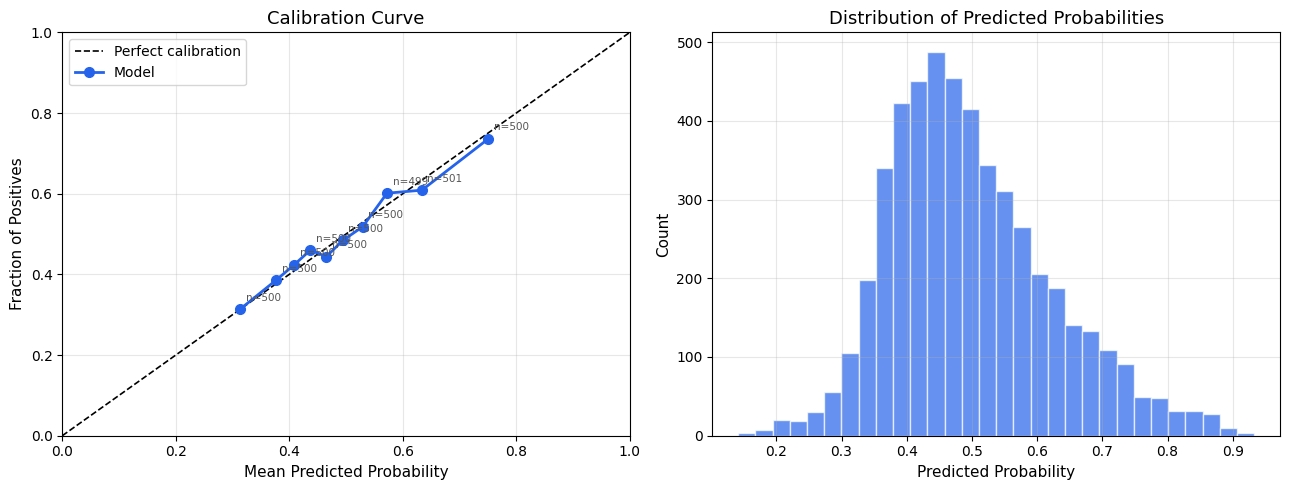

checking calibration for subset ['V390', 'V224', 'V175', 'V32', 'V11', 'V199', 'V345', 'V309']
Bin  1 | n= 500 | mean_pred=0.263 | frac_pos=0.330
Bin  2 | n= 500 | mean_pred=0.344 | frac_pos=0.402
Bin  3 | n= 500 | mean_pred=0.386 | frac_pos=0.416
Bin  4 | n= 500 | mean_pred=0.424 | frac_pos=0.390
Bin  5 | n= 500 | mean_pred=0.460 | frac_pos=0.458
Bin  6 | n= 500 | mean_pred=0.500 | frac_pos=0.482
Bin  7 | n= 500 | mean_pred=0.545 | frac_pos=0.550
Bin  8 | n= 500 | mean_pred=0.598 | frac_pos=0.602
Bin  9 | n= 500 | mean_pred=0.668 | frac_pos=0.664
Bin 10 | n= 500 | mean_pred=0.795 | frac_pos=0.682


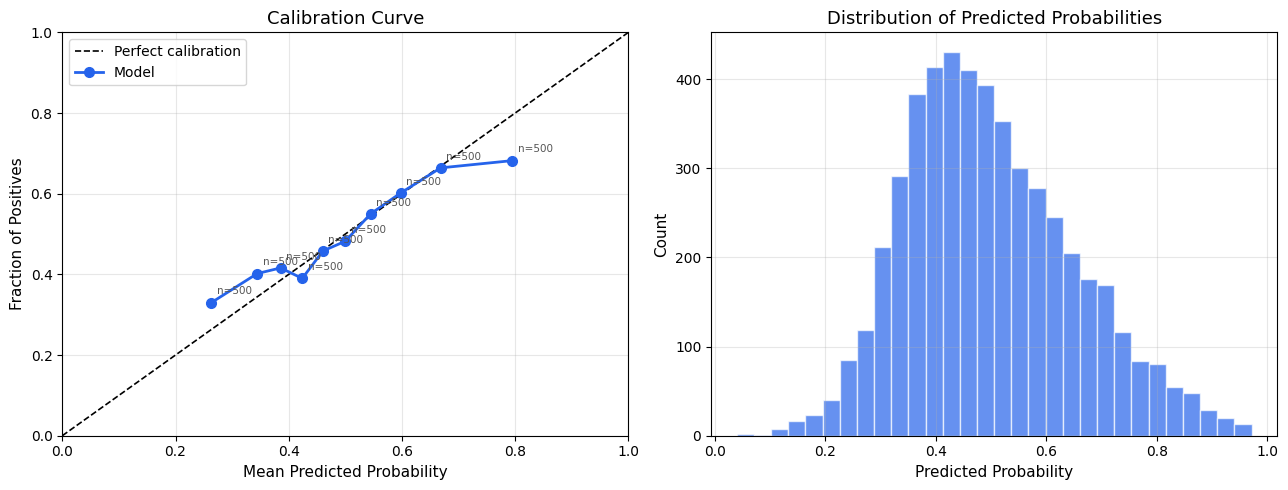

checking calibration for subset ['V390', 'V161', 'V175', 'V32', 'V11', 'V199', 'V345', 'V329']
Bin  1 | n= 500 | mean_pred=0.221 | frac_pos=0.332
Bin  2 | n= 500 | mean_pred=0.317 | frac_pos=0.428
Bin  3 | n= 500 | mean_pred=0.370 | frac_pos=0.458
Bin  4 | n= 500 | mean_pred=0.416 | frac_pos=0.426
Bin  5 | n= 500 | mean_pred=0.458 | frac_pos=0.472
Bin  6 | n= 500 | mean_pred=0.505 | frac_pos=0.478
Bin  7 | n= 500 | mean_pred=0.555 | frac_pos=0.500
Bin  8 | n= 500 | mean_pred=0.613 | frac_pos=0.572
Bin  9 | n= 500 | mean_pred=0.696 | frac_pos=0.608
Bin 10 | n= 500 | mean_pred=0.834 | frac_pos=0.702


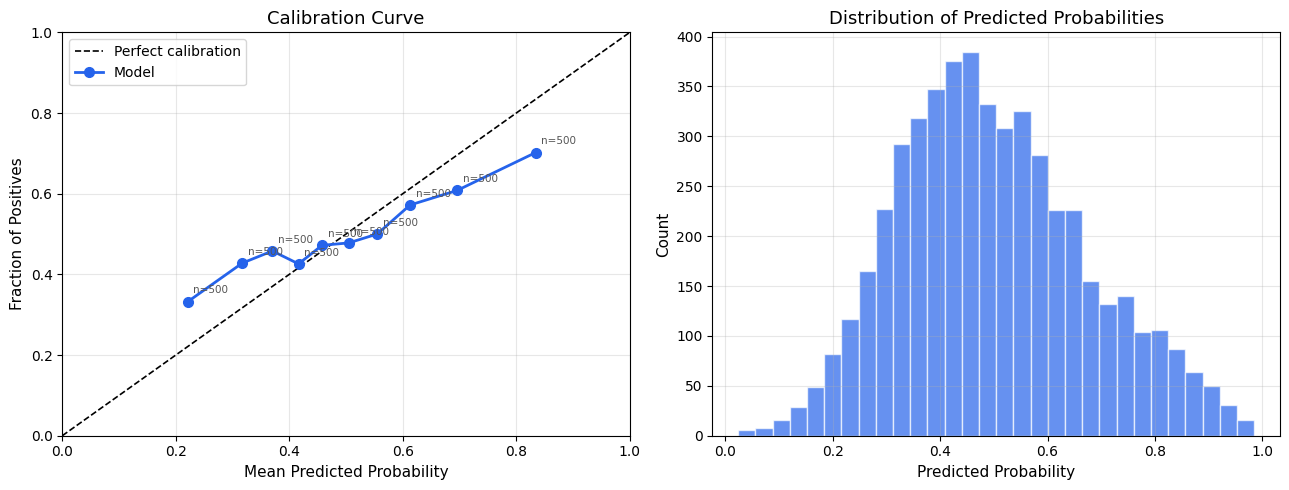

checking calibration for subset ['V390', 'V175', 'V32', 'V11', 'V199', 'V345', 'V309']
Bin  1 | n= 500 | mean_pred=0.314 | frac_pos=0.314
Bin  2 | n= 500 | mean_pred=0.377 | frac_pos=0.386
Bin  3 | n= 500 | mean_pred=0.409 | frac_pos=0.424
Bin  4 | n= 500 | mean_pred=0.437 | frac_pos=0.460
Bin  5 | n= 500 | mean_pred=0.465 | frac_pos=0.444
Bin  6 | n= 500 | mean_pred=0.494 | frac_pos=0.484
Bin  7 | n= 500 | mean_pred=0.529 | frac_pos=0.518
Bin  8 | n= 499 | mean_pred=0.572 | frac_pos=0.601
Bin  9 | n= 501 | mean_pred=0.634 | frac_pos=0.609
Bin 10 | n= 500 | mean_pred=0.751 | frac_pos=0.736


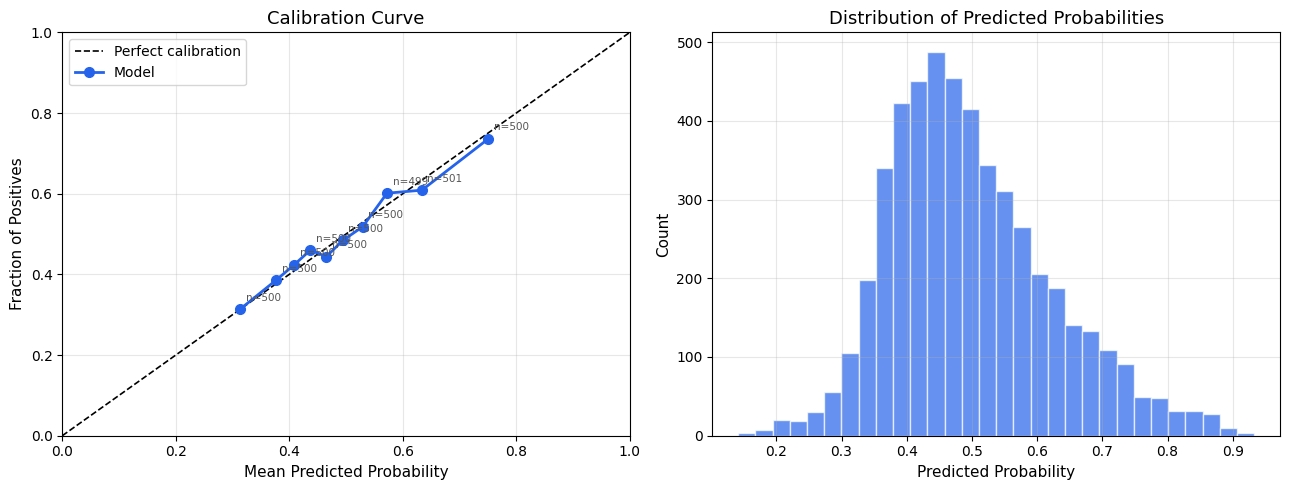

In [22]:
for ind in top10_subset_indices:
    print(f"checking calibration for subset {top10_hyperparameter_tuning_result_dict[ind]['subset_list']}")
    model=XGBClassifier(max_depth=top10_hyperparameter_tuning_result_dict[ind]['best_c_hyperparams']['max_depth'])
    all_y_test,all_y_prob=get_cv_calibration_predictions(model,x.loc[:,top10_hyperparameter_tuning_result_dict[ind]['subset_list']],y)
    check_calibration(all_y_prob,all_y_test,savename=Path(PLOT_DIR / f"calibration_for_subset_{ind}"))
    print("===============================================")